Analysis of the historical data of a fantasy hockey league. The Brave Braves are the definitive dynasty of the league, holding 5 of the top 10 greatest seasons of all time. Meanwhile, Krylia Sovetov and Vecherniy Chelyabinsk frequently find themselves at the bottom of the standings.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# mapping the Season Year to the respective filename
season_files = {
    2025_26: 'data\\RHFL_matchups_2526.csv',
    2024_25: 'data\\RHFL_matchups_2425.csv',
    2023_24: 'data\\RHFL_matchups_2324.csv',
    2022_23: 'data\\RHFL_matchups_2223.csv',
    2021_22: 'data\\RHFL_matchups_2122.csv',
    2020_21: 'data\\RHFL_matchups_2021.csv',
    2019_20: 'data\\RHFL_matchups_1920.csv',
    2018_19: 'data\\RHFL_matchups_1819.csv',
    2017_18: 'data\\RHFL_matchups_1718.csv',
    2016_17: 'data\\RHFL_matchups_1617.csv',
    2015_16: 'data\\RHFL_matchups_1516.csv',
    2014_15: 'data\\RHFL_matchups_1415.csv',
    2013_14: 'data\\RHFL_matchups_1314.csv',
    2012_13: 'data\\RHFL_matchups_1213.csv',
}

all_seasons_list = []

# Looping through each file, cleaning it, reshapeing it, and tagging it with the year
for season, filename in season_files.items():
    
    # --- READ AND CLEAN ---
    df = pd.read_csv(filename, names=[0, 1, 2, 3])
    
    period_mask = df[0].str.contains('Scoring Period', na=False)
    df['Week'] = df[0].where(period_mask).str.extract(r'(\d+)')
    df['Week'] = df['Week'].ffill()
    
    df_clean = df[~df[0].str.contains('Scoring Period|Away', na=False)].copy()
    df_clean = df_clean.dropna(subset=[0, 1, 2, 3], how='all')
    
    df_clean.columns = ['Away', 'Away_FPts', 'Home', 'Home_FPts', 'Week']
    df_clean['Away_FPts'] = pd.to_numeric(df_clean['Away_FPts'])
    df_clean['Home_FPts'] = pd.to_numeric(df_clean['Home_FPts'])
    df_clean['Week'] = df_clean['Week'].astype(int)
    
    # --- RESHAPE ---
    df_away = df_clean[['Week', 'Away', 'Away_FPts']].rename(
        columns={'Away': 'Team', 'Away_FPts': 'Score'}
    )
    df_home = df_clean[['Week', 'Home', 'Home_FPts']].rename(
        columns={'Home': 'Team', 'Home_FPts': 'Score'}
    )
    
    df_season = pd.concat([df_away, df_home], ignore_index=True)
    
    # --- ADD THE SEASON TAG ---
    df_season['Season'] = season
    
    all_seasons_list.append(df_season)

# Combine everything
df_historical = pd.concat(all_seasons_list, ignore_index=True)
df_historical = df_historical[['Season', 'Week', 'Team', 'Score']]

print(df_historical.head())
print("\nTotal historical matchups loaded:", len(df_historical))

   Season  Week            Team   Score
0  202526     1    Hear me Roar  180.68
1  202526     1    Brave Braves  201.11
2  202526     1    Suomi Flyers  166.07
3  202526     1       Bobby Orr  191.60
4  202526     1  Teftonic Order  221.38

Total historical matchups loaded: 4640


Making the team names consistent

In [13]:
def audit_team_names(df):
    total_seasons = df['Season'].nunique()
    
    # Group by Team and aggregate their active seasons
    # 'unique' gives us a list of the exact years they played
    # 'nunique' counts how many distinct years they played
    team_audit = df.groupby('Team')['Season'].agg(['unique', 'nunique']).reset_index()
    team_audit.columns = ['Team', 'Seasons_Played', 'Season_Count']
    
    # Sort the lists of seasons so they are easy to read
    team_audit['Seasons_Played'] = team_audit['Seasons_Played'].apply(lambda x: sorted(list(x)))
    
    # Separate the consistent teams from the irregular ones
    consistent = team_audit[team_audit['Season_Count'] == total_seasons].copy()
    changed = team_audit[team_audit['Season_Count'] < total_seasons].copy()
    
    # Sort the changed teams by their active years to make matching them up easier
    changed['Sort_Key'] = changed['Seasons_Played'].apply(lambda x: x[0])
    changed = changed.sort_values(by=['Sort_Key', 'Team']).drop(columns=['Sort_Key'])
    
    return consistent, changed

# Run the audit
consistent_teams, changed_teams = audit_team_names(df_historical)

print("✅ TEAMS WITH CONSISTENT NAMES (Played in all seasons):")
print("-" * 55)
print(consistent_teams[['Team', 'Seasons_Played']].to_string(index=False))

print("\n⚠️ TEAMS THAT CHANGED NAMES, JOINED, OR LEFT:")
print("-" * 55)
print(changed_teams[['Team', 'Seasons_Played']].to_string(index=False))

✅ TEAMS WITH CONSISTENT NAMES (Played in all seasons):
-------------------------------------------------------
                Team                                                                                                   Seasons_Played
           Bobby Orr [201213, 201314, 201415, 201516, 201617, 201718, 201819, 201920, 202021, 202122, 202223, 202324, 202425, 202526]
        Brave Braves [201213, 201314, 201415, 201516, 201617, 201718, 201819, 201920, 202021, 202122, 202223, 202324, 202425, 202526]
        Hear me Roar [201213, 201314, 201415, 201516, 201617, 201718, 201819, 201920, 202021, 202122, 202223, 202324, 202425, 202526]
            Ice Bolt [201213, 201314, 201415, 201516, 201617, 201718, 201819, 201920, 202021, 202122, 202223, 202324, 202425, 202526]
Novopolotsk Berserks [201213, 201314, 201415, 201516, 201617, 201718, 201819, 201920, 202021, 202122, 202223, 202324, 202425, 202526]
         Sagitarusus [201213, 201314, 201415, 201516, 201617, 201718, 201819, 201920,

In [14]:
name_mapping = {
    # 'Old Name': 'Current Name'
    'Chudovischa': 'Uncle Kopitar and his Chudovischa',
    'Krylya Sovetov': 'Angry Penguins',
    'Pucking Awesome': 'Angry Penguins',
    'Razorbacks': 'Steel Lynxes',
    'Teft Ultimate Avenger': 'Teftonic Order',
    'Terrible Chepa Razorback': 'Steel Lynxes',
    'Vagrant Dogs': 'Krylia Sovetov',
    'Be Calm': 'Champions of tomorrow',
    'Taylor Swift\'s Dominion': 'Champions of tomorrow',
    'Deepest Mode': 'Champions of tomorrow',
    'banda akata': 'Vecherniy Chelyabinsk',
    'Riga Mavericks': 'Suomi Flyers',
    'Spartans': 'Murmansk Pigs'
}

df_historical['Team'] = df_historical['Team'].replace(name_mapping)

print("✅ Name unification complete. Here are the unique teams now in the dataset:")
print(df_historical['Team'].sort_values().unique())

✅ Name unification complete. Here are the unique teams now in the dataset:
['Angry Penguins' 'Bobby Orr' 'Brave Braves' 'Champions of tomorrow'
 'Hear me Roar' 'Ice Bolt' 'Krylia Sovetov' 'Murmansk Pigs'
 'Novopolotsk Berserks' 'Sagitarusus' 'South Ural Wings' 'Steel Lynxes'
 'Suomi Flyers' 'Teftonic Order' 'Uncle Kopitar and his Chudovischa'
 'Vecherniy Chelyabinsk']


To eliminate the luck of schedule strength, we calculate each team's record against the entire field every week for each season

In [15]:

def calculate_historical_all_play(df, start_season=None, end_season=None):
    """
    Calculates all-time 'vs the field' standings across multiple seasons.
    """
    # Filter by season if requested
    if start_season is not None:
        df = df[df['Season'] >= start_season]
    if end_season is not None:
        df = df[df['Season'] <= end_season]
        
    if df.empty:
        return "No data found for the selected timeframe."

    # Group by BOTH Season and Week!
    weekly_team_counts = df.groupby(['Season', 'Week'])['Team'].transform('count')
    
    # Calculate Wins and Losses for each specific week of each season
    df['W'] = df.groupby(['Season', 'Week'])['Score'].rank(method='min', ascending=True) - 1
    df['L'] = weekly_team_counts - df.groupby(['Season', 'Week'])['Score'].rank(method='max', ascending=True)
    
    # Aggregate everything together by Team for the all-time leaderboard
    standings = df.groupby('Team')[['W', 'L']].sum().reset_index()
    
    # Add all-time Total Scores
    total_scores = df.groupby('Team')['Score'].sum().reset_index()
    standings = standings.merge(total_scores, on='Team')
    
    # Clean up formatting
    for col in ['W', 'L']:
        standings[col] = standings[col].astype(int)
        
    # Calculate overall Win Percentage
    total_games = standings['W'] + standings['L']
    standings['Win %'] = standings['W'] / total_games.replace(0, 1)
    
    # Sort for the final leaderboard
    standings = standings.sort_values(by=['Win %', 'Score'], ascending=[False, False]).reset_index(drop=True)
    standings = standings[['Team', 'W', 'L', 'Win %', 'Score']]
    
    return standings

# ==========================================
# EXAMPLES OF HOW TO USE IT:
# ==========================================

# The Ultimate All-Time Leaderboard
all_time_standings = calculate_historical_all_play(df_historical)
#print("--- ALL-TIME LEAGUE STANDINGS ---")
#print(all_time_standings)

# "Modern Era" Leaderboard (e.g., 2020 to Present)
modern_standings = calculate_historical_all_play(df_historical, start_season=202526, end_season=202526)
print("\n--- STANDINGS")
print(modern_standings)


--- STANDINGS
                                 Team    W    L     Win %    Score
0                        Brave Braves  281   49  0.851515  6502.52
1                      Angry Penguins  268   62  0.812121  6283.05
2                      Krylia Sovetov  248   82  0.751515  5994.13
3                      Teftonic Order  219  111  0.663636  5579.37
4                    South Ural Wings  218  112  0.660606  5737.67
5                Novopolotsk Berserks  217  113  0.657576  5580.18
6               Champions of tomorrow  204  126  0.618182  5493.79
7                        Hear me Roar  199  131  0.603030  5546.44
8                        Suomi Flyers  168  162  0.509091  5192.56
9   Uncle Kopitar and his Chudovischa  155  175  0.469697  5013.54
10                          Bobby Orr  142  188  0.430303  4880.42
11                           Ice Bolt   89  241  0.269697  4227.36
12                        Sagitarusus   88  242  0.266667  4261.76
13                       Steel Lynxes   79  251

Finding the best team seasons 

In [ ]:
def get_best_individual_seasons(df, top_n=15):
    """
    Calculates the best individual seasons in league history based on 
    'vs the field' Win Percentage.
    """
    # Calculate Weekly W/L 
    weekly_team_counts = df.groupby(['Season', 'Week'])['Team'].transform('count')
    
    df['W'] = df.groupby(['Season', 'Week'])['Score'].rank(method='min', ascending=True) - 1
    df['L'] = weekly_team_counts - df.groupby(['Season', 'Week'])['Score'].rank(method='max', ascending=True)
    
    # Aggregate by both Season and Team
    # This creates a separate final record for every individual year a team played
    season_standings = df.groupby(['Season', 'Team'])[['W', 'L']].sum().reset_index()
    
    # Add Total Scores for that specific season (used as a tiebreaker)
    season_scores = df.groupby(['Season', 'Team'])['Score'].sum().reset_index()
    season_standings = season_standings.merge(season_scores, on=['Season', 'Team'])
    
    # Clean up formatting and calculate Win %
    for col in ['W', 'L']:
        season_standings[col] = season_standings[col].astype(int)
        
    total_games = season_standings['W'] + season_standings['L']
    season_standings['Win %'] = season_standings['W'] / total_games.replace(0, 1)
    
    # Highest Win % first, then Highest Total Score to break ties
    best_seasons = season_standings.sort_values(
        by=['Win %', 'Score'], 
        ascending=[False, False]
    ).reset_index(drop=True)
    
    best_seasons = best_seasons[['Season', 'Team', 'W', 'L', 'Win %', 'Score']]
    
    # Return selected number of top teams
    return best_seasons.head(top_n)

# ==========================================
# HOW TO USE IT:
# ==========================================

top_seasons = get_best_individual_seasons(df_historical, top_n=10)

print("🏆 GREATEST INDIVIDUAL SEASONS IN LEAGUE HISTORY 🏆")
print("-" * 65)
print(top_seasons.to_string(index=False))

🏆 GREATEST INDIVIDUAL SEASONS IN LEAGUE HISTORY 🏆
-----------------------------------------------------------------
 Season                 Team   W  L    Win %   Score
 201617         Brave Braves 296 34 0.896970 6527.45
 201415         Brave Braves 291 39 0.881818 6684.45
 201213       Teftonic Order 144 21 0.872727 3780.60
 201314         Brave Braves 286 44 0.866667 6579.45
 202526         Brave Braves 281 49 0.851515 6502.52
 202324     South Ural Wings 275 55 0.833333 6650.27
 201516         Brave Braves 272 58 0.824242 6556.60
 202526       Angry Penguins 268 62 0.812121 6283.05
 201415 Novopolotsk Berserks 268 62 0.812121 6281.35
 201819         Brave Braves 265 65 0.803030 6452.30


Finding the worst team seasons

In [ ]:
def get_worst_individual_seasons(df, top_n=15):
    """
    Calculates the worst individual seasons in league history based on 
    'vs the field' Win Percentage.
    """
    # Calculate Weekly W/L
    weekly_team_counts = df.groupby(['Season', 'Week'])['Team'].transform('count')
    df['W'] = df.groupby(['Season', 'Week'])['Score'].rank(method='min', ascending=True) - 1
    df['L'] = weekly_team_counts - df.groupby(['Season', 'Week'])['Score'].rank(method='max', ascending=True)
    
    # Aggregate by both Season and Team
    season_standings = df.groupby(['Season', 'Team'])[['W', 'L']].sum().reset_index()
    season_scores = df.groupby(['Season', 'Team'])['Score'].sum().reset_index()
    season_standings = season_standings.merge(season_scores, on=['Season', 'Team'])
    
    # Clean formatting and calculate Win %
    for col in ['W', 'L']:
        season_standings[col] = season_standings[col].astype(int)
        
    total_games = season_standings['W'] + season_standings['L']
    season_standings['Win %'] = season_standings['W'] / total_games.replace(0, 1)
    
    # Sort to find the worst seasons
    # Lowest Win % first, then Lowest Total Score to break ties
    worst_seasons = season_standings.sort_values(
        by=['Win %', 'Score'], 
        ascending=[True, True]
    ).reset_index(drop=True)
    
    worst_seasons = worst_seasons[['Season', 'Team', 'W', 'L', 'Win %', 'Score']]
    
    # Return the top_n worst
    return worst_seasons.head(top_n)

# ==========================================
# HOW TO USE IT:
# ==========================================

bottom_seasons = get_worst_individual_seasons(df_historical, top_n=15)

print("📉 THE WORST INDIVIDUAL SEASONS IN LEAGUE HISTORY 📉")
print("-" * 65)
print(bottom_seasons.to_string(index=False))

📉 THE WORST INDIVIDUAL SEASONS IN LEAGUE HISTORY 📉
-----------------------------------------------------------------
 Season                  Team  W   L    Win %   Score
 201920  Novopolotsk Berserks 19 311 0.057576 3526.85
 202526 Vecherniy Chelyabinsk 30 300 0.090909 3400.37
 201819        Krylia Sovetov 30 300 0.090909 3876.95
 202324              Ice Bolt 32 298 0.096970 4124.30
 201718 Vecherniy Chelyabinsk 34 296 0.103030 4012.95
 201718        Krylia Sovetov 34 296 0.103030 4102.60
 202526         Murmansk Pigs 35 295 0.106061 3466.58
 202021        Angry Penguins 27 198 0.120000 2408.65
 202425 Vecherniy Chelyabinsk 46 284 0.139394 3673.23
 201415              Ice Bolt 46 284 0.139394 4049.85
 201516          Steel Lynxes 48 282 0.145455 4224.50
 202223        Krylia Sovetov 49 281 0.148485 4421.21
 202122        Krylia Sovetov 49 281 0.148485 4495.85
 201415          Steel Lynxes 55 275 0.166667 4344.00
 201617        Angry Penguins 58 272 0.175758 4248.90


Calculating historical Head-2-Head records

In [18]:
matchup_list = []

for year, filename in season_files.items():
    # Read and clean the basic structure just like before
    df = pd.read_csv(filename, names=[0, 1, 2, 3])
    period_mask = df[0].str.contains('Scoring Period', na=False)
    df['Week'] = df[0].where(period_mask).str.extract(r'(\d+)').ffill()
    
    df_clean = df[~df[0].str.contains('Scoring Period|Away', na=False)].copy()
    df_clean = df_clean.dropna(subset=[0, 1, 2, 3], how='all')
    df_clean.columns = ['Away', 'Away_FPts', 'Home', 'Home_FPts', 'Week']
    
    # Add the season tag
    df_clean['Season'] = year
    matchup_list.append(df_clean)

# Combine all seasons into one master schedule
df_schedule = pd.concat(matchup_list, ignore_index=True)

df_schedule['Away'] = df_schedule['Away'].replace(name_mapping)
df_schedule['Home'] = df_schedule['Home'].replace(name_mapping)

df_schedule['Away_FPts'] = pd.to_numeric(df_schedule['Away_FPts'])
df_schedule['Home_FPts'] = pd.to_numeric(df_schedule['Home_FPts'])


# CREATE A UNIFIED PERSPECTIVE FOR EACH TEAM
# Perspective 1: Away Team
df_away_view = df_schedule[['Season', 'Week', 'Away', 'Away_FPts', 'Home', 'Home_FPts']].copy()
df_away_view.columns = ['Season', 'Week', 'Team', 'Team_Score', 'Opponent', 'Opp_Score']

# Perspective 2: Home Team
df_home_view = df_schedule[['Season', 'Week', 'Home', 'Home_FPts', 'Away', 'Away_FPts']].copy()
df_home_view.columns = ['Season', 'Week', 'Team', 'Team_Score', 'Opponent', 'Opp_Score']

# Stack them together
df_actual_h2h = pd.concat([df_away_view, df_home_view], ignore_index=True)

# CALCULATE ACTUAL WINS AND LOSSES
df_actual_h2h['W'] = (df_actual_h2h['Team_Score'] > df_actual_h2h['Opp_Score']).astype(int)
df_actual_h2h['L'] = (df_actual_h2h['Team_Score'] < df_actual_h2h['Opp_Score']).astype(int)
df_actual_h2h['T'] = (df_actual_h2h['Team_Score'] == df_actual_h2h['Opp_Score']).astype(int)

# AGGREGATE THE FINAL RECORDS
true_h2h_records = df_actual_h2h.groupby(['Team', 'Opponent'])[['W', 'L', 'T']].sum().reset_index()

true_h2h_records['Record'] = true_h2h_records['W'].astype(str) + "-" + true_h2h_records['L'].astype(str)

# Pivot into the Head-to-Head Matrix Grid
true_h2h_matrix = true_h2h_records.pivot(index='Team', columns='Opponent', values='Record')
true_h2h_matrix = true_h2h_matrix.fillna('-')

print("📊 ACTUAL HEAD-TO-HEAD WIN/LOSS MATRIX 📊")
print(true_h2h_matrix)

true_h2h_matrix.to_csv('Actual_H2H_Matrix.csv')

📊 ACTUAL HEAD-TO-HEAD WIN/LOSS MATRIX 📊
Opponent                          Angry Penguins Bobby Orr Brave Braves  \
Team                                                                      
Angry Penguins                                 -     14-11         5-21   
Bobby Orr                                  11-14         -         4-22   
Brave Braves                                21-5      22-4            -   
Champions of tomorrow                      10-16      9-15         7-18   
Hear me Roar                                 9-5      10-5          5-9   
Ice Bolt                                     6-7       8-7         1-14   
Krylia Sovetov                               8-6       5-9         1-14   
Murmansk Pigs                               5-10       6-7         3-11   
Novopolotsk Berserks                        9-15     12-14         3-22   
Sagitarusus                                  9-5       6-8         3-10   
South Ural Wings                             9-4      10-5  

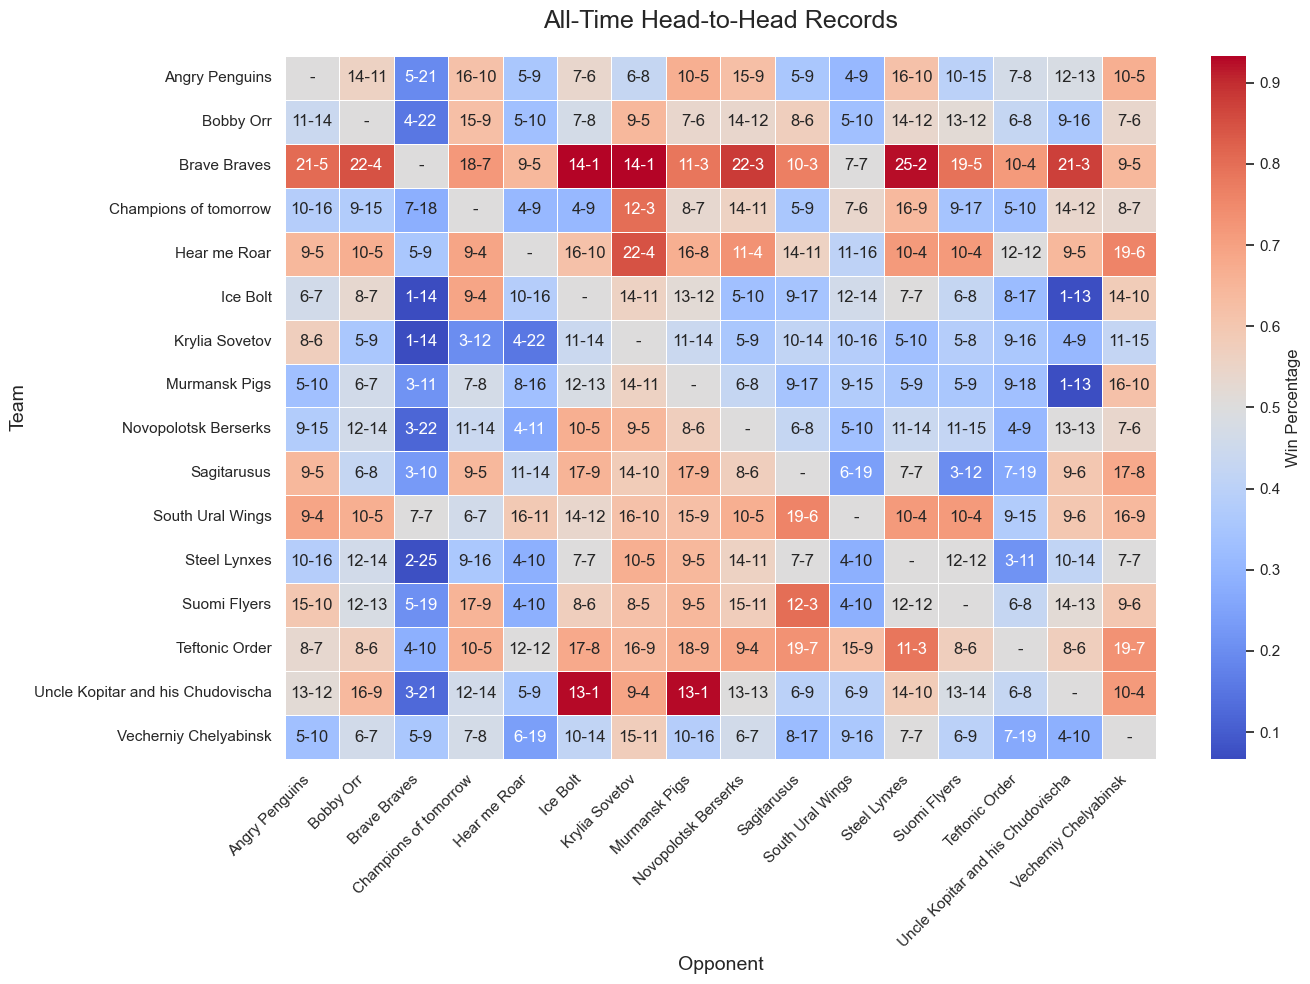

In [ ]:
# Calculate the H2H Win Percentage for the color scale
true_h2h_records['Total_Games'] = true_h2h_records['W'] + true_h2h_records['L'] + true_h2h_records['T']
true_h2h_records['Win_Pct'] = true_h2h_records['W'] / true_h2h_records['Total_Games'].replace(0, 1)

# Pivot the numeric data for the heatmap colors
heatmap_data = true_h2h_records.pivot(index='Team', columns='Opponent', values='Win_Pct')
heatmap_data = heatmap_data.fillna(0.5) # Fill non-matchups (playing themselves) with 0.5 for neutral color

# Visualization
plt.figure(figsize=(14, 10))
sns.set_theme(style="white")

# Draw the heatmap
ax = sns.heatmap(
    heatmap_data, 
    annot=true_h2h_matrix, 
    fmt="",                
    cmap="coolwarm",       
    linewidths=.5, 
    cbar_kws={'label': 'Win Percentage'}
)

plt.title('All-Time Head-to-Head Records', fontsize=18, pad=20)
plt.ylabel('Team', fontsize=14)
plt.xlabel('Opponent', fontsize=14)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()

plt.show()

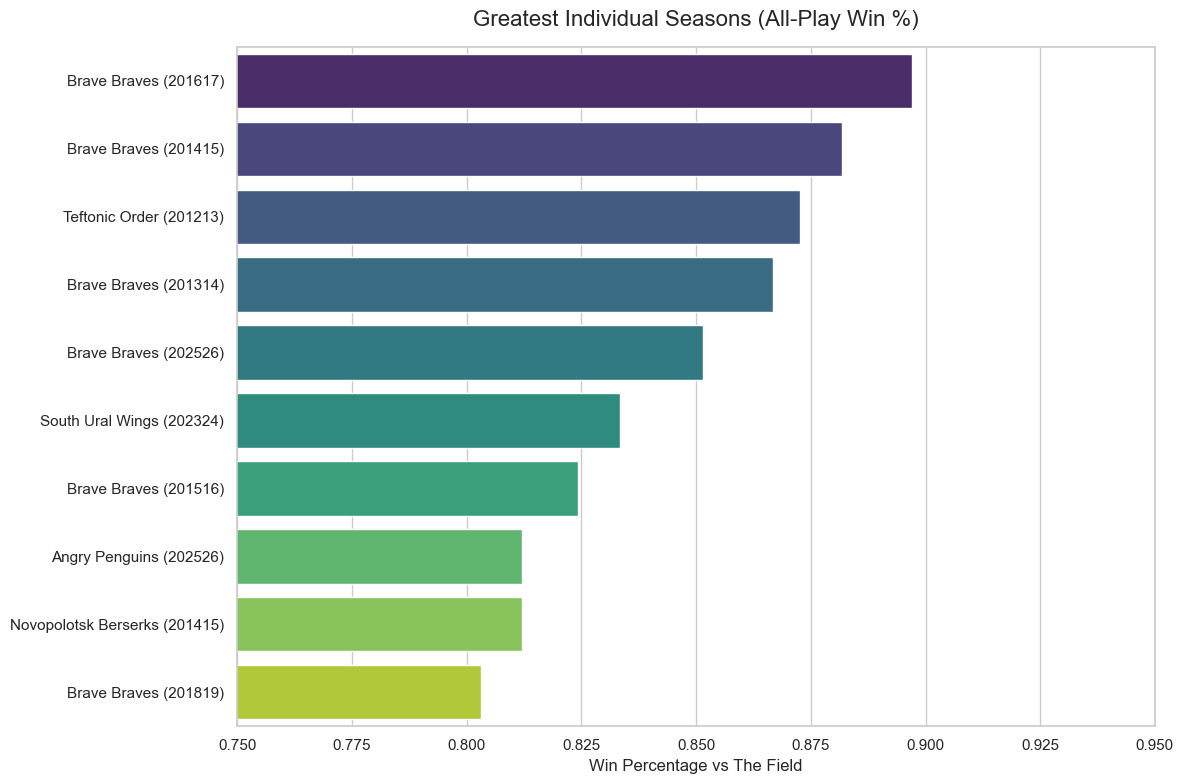

In [ ]:
# Creating a combined label for the Y-axis
top_seasons['Season_Team'] = top_seasons['Team'] + " (" + top_seasons['Season'].astype(str) + ")"

# Visualization
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=top_seasons, 
    x='Win %', 
    y='Season_Team',
    hue='Season_Team',  
    palette="viridis",
    legend=False        
)

# Add titles and labels
plt.title('Greatest Individual Seasons (All-Play Win %)', fontsize=16, pad=15)
plt.xlabel('Win Percentage vs The Field', fontsize=12)
plt.ylabel('', fontsize=12)

plt.xlim(0.75, 0.95) 

plt.tight_layout()
plt.show()

Visualizing All Play Win% over time for individual teams

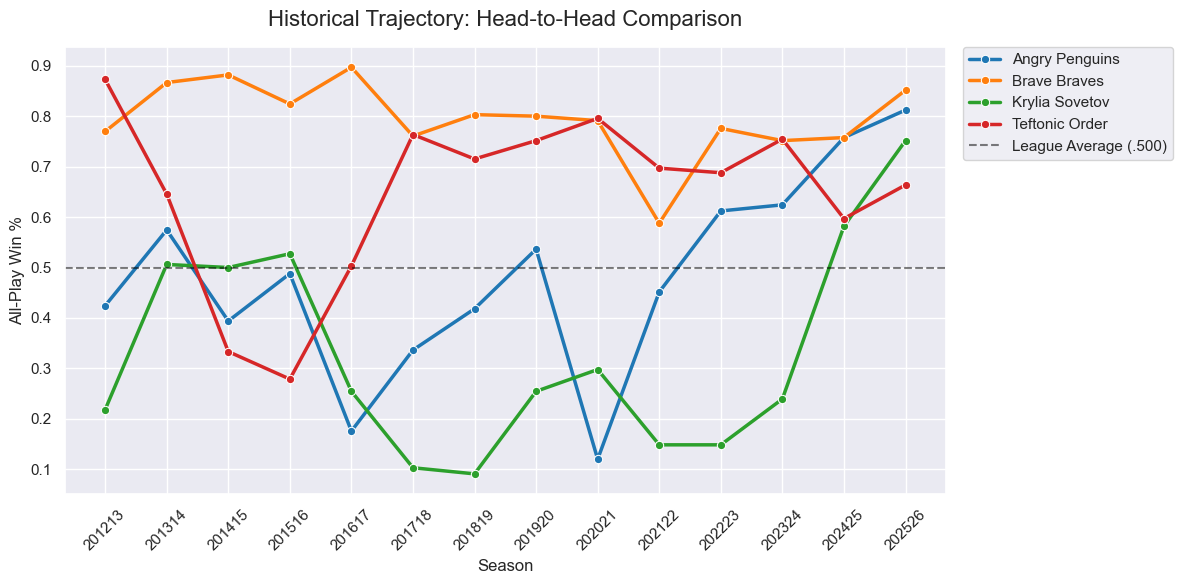

In [31]:
# Teams to highlight
target_teams = ["Brave Braves", "Angry Penguins", "Teftonic Order", "Krylia Sovetov"]

team_data = season_trends[season_trends['Team'].isin(target_teams)]

# Visualization
plt.figure(figsize=(12, 6))
sns.set_theme(style="darkgrid")

sns.lineplot(
    data=team_data, 
    x='Season', 
    y='Win %', 
    hue='Team',      
    marker='o', 
    linewidth=2.5,   
    palette="tab10" 
)

# Reference line for a .500 record (average)
plt.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='League Average (.500)')

# Formatting
plt.title('Historical Trajectory: Head-to-Head Comparison', fontsize=16, pad=15)
plt.xlabel('Season', fontsize=12)
plt.ylabel('All-Play Win %', fontsize=12)

seasons_list = sorted(team_data['Season'].unique())
plt.xticks(seasons_list, [str(s) for s in seasons_list], rotation=45)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()